# Experiment 1: Data Analysis on Employee Information

This notebook demonstrates exploratory data analysis (EDA) and data visualization on the `employee_information_100.csv` dataset, covering departmental aggregations, distributions, demographic breakdowns, and correlation analysis.

## 1. Environment Setup and Dataset Loading

Load essential libraries (`pandas`, `matplotlib`, `seaborn`) and inspect the first five records.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('employee_information_100.csv')
df.head()

,Employee_ID,Name,Department,Age,Gender,Salary,Experience_Years
0,E001,Diana1,HR,39,Male,58000,8
1,E002,Diana2,Operations,56,Male,105000,27
2,E003,Bob3,HR,27,Male,59000,32
3,E004,Neha4,HR,57,Male,113000,34
4,E005,Nisha5,IT,50,Female,30000,10


## Experiment 1.1: Average Salary by Department (Bar Chart)

Calculate the mean salary for each department and visualize the results using a bar chart.

   Department        Salary
0     Finance  82416.666667
1          HR  72095.238095
2          IT  73611.111111
3   Marketing  76100.000000
4  Operations  90875.000000
5       Sales  74769.230769


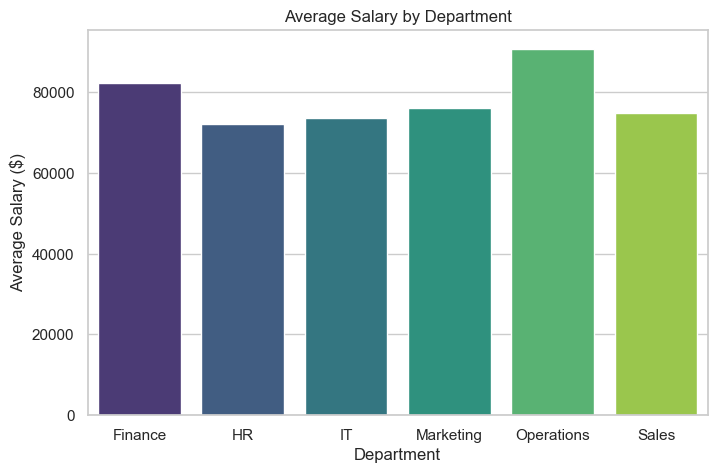

In [2]:
avg_salary = df.groupby('Department')['Salary'].mean().reset_index()
print(avg_salary)

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_salary, x='Department', y='Salary', hue='Department', palette='viridis', legend=False)
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary ($)')
plt.show()

## Experiment 1.2: Number of Employees in Each Department

Compute the headcount per department and display the distribution with a bar chart.

   Department  Employee_Count
0          HR              21
1   Marketing              20
2          IT              18
3  Operations              16
4       Sales              13
5     Finance              12


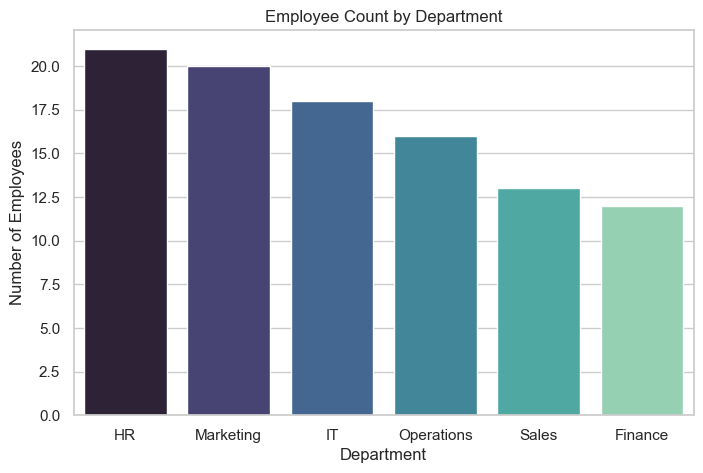

In [3]:
dept_counts = df['Department'].value_counts().reset_index()
dept_counts.columns = ['Department', 'Employee_Count']
print(dept_counts)

plt.figure(figsize=(8, 5))
sns.barplot(data=dept_counts, x='Department', y='Employee_Count', hue='Department', palette='mako', legend=False)
plt.title('Employee Count by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.show()

## Experiment 1.3: Percentage of Male and Female Employees (Pie Chart)

Determine the gender ratio across the organization and visualize using a pie chart.

Gender
Male      64
Female    36
Name: count, dtype: int64


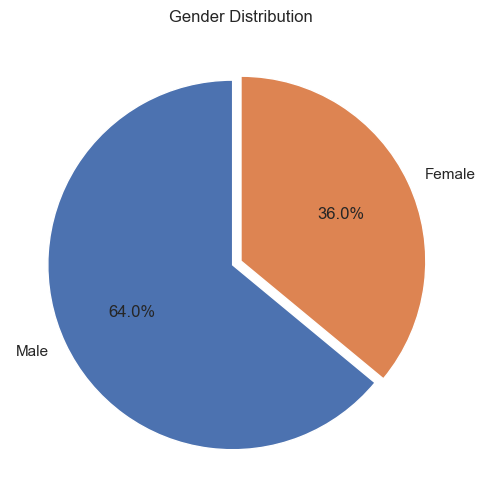

In [4]:
gender_counts = df['Gender'].value_counts()
print(gender_counts)

plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452'], explode=(0.05, 0))
plt.title('Gender Distribution')
plt.show()

## Experiment 1.4: Salary Distribution (Histogram)

Plot a histogram with Kernel Density Estimation (KDE) to visualize salary spread.

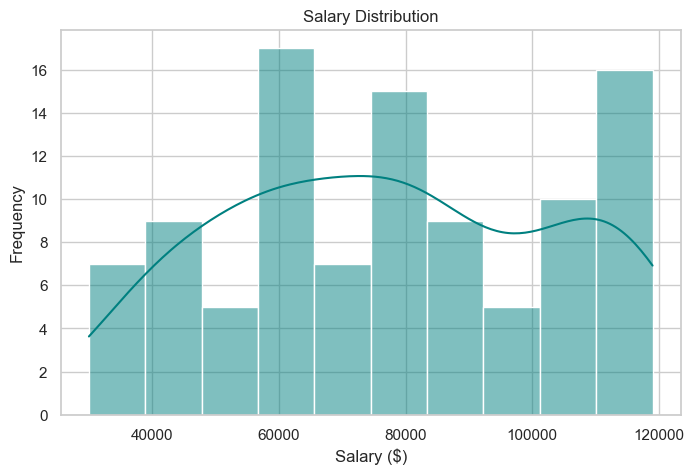

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Salary'], bins=10, kde=True, color='teal')
plt.title('Salary Distribution')
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')
plt.show()

## Experiment 1.5: Relationship Between Experience and Salary (Scatter Plot)

Analyze correlation between years of experience and salary across departments.

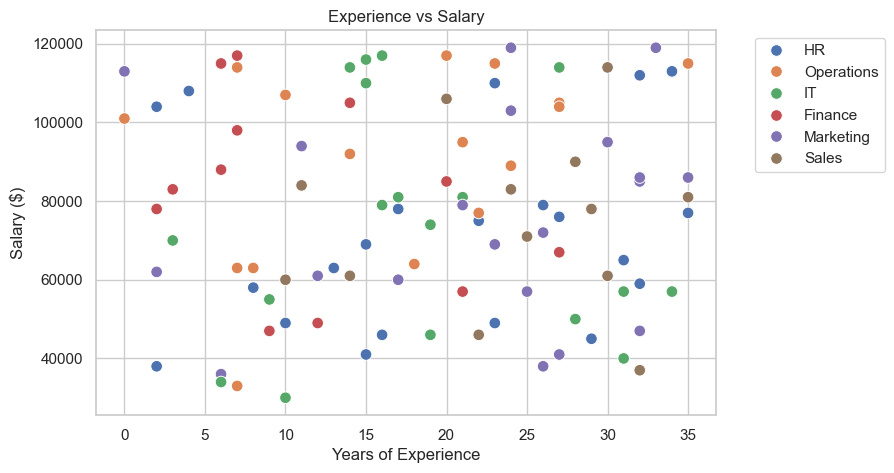

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Experience_Years', y='Salary', hue='Department', s=70)
plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Experiment 1.6: Top 10 Employees with Highest Salary

Identify and display the top 10 highest-earning employees.

In [7]:
top_10_salary = df.nlargest(10, 'Salary')
top_10_salary[['Employee_ID', 'Name', 'Department', 'Salary', 'Experience_Years']]

,Employee_ID,Name,Department,Salary,Experience_Years
85,E086,Omar86,Marketing,119000,24
87,E088,Diana88,Marketing,119000,33
14,E015,Ishan15,Operations,117000,20
22,E023,Rahul23,Finance,117000,7
58,E059,Neha59,IT,117000,16
48,E049,Charlie49,IT,116000,15
31,E032,George32,Operations,115000,23
55,E056,Sneha56,Operations,115000,35
64,E065,Bob65,Finance,115000,6
9,E010,Vikram10,IT,114000,14


## Experiment 1.7: Highest Salary in Every Department

Find the maximum compensation level achieved within each department.

In [8]:
highest_salary_dept = df.groupby('Department')['Salary'].max().reset_index()
highest_salary_dept

,Department,Salary
0,Finance,117000
1,HR,113000
2,IT,117000
3,Marketing,119000
4,Operations,117000
5,Sales,114000


## Experiment 1.8: Employees Earning Above the Overall Average Salary

Filter and display employees whose compensation exceeds the company-wide average.

In [9]:
overall_avg_salary = df['Salary'].mean()
print(f"Overall Average Salary: {overall_avg_salary:.2f}")

above_avg_employees = df[df['Salary'] > overall_avg_salary]
print(f"Total employees with above-average salary: {len(above_avg_employees)}")
above_avg_employees[['Employee_ID', 'Name', 'Department', 'Salary', 'Experience_Years']].head(10)

Overall Average Salary: 77760.00
Total employees with above-average salary: 51


,Employee_ID,Name,Department,Salary,Experience_Years
1,E002,Diana2,Operations,105000,27
3,E004,Neha4,HR,113000,34
7,E008,Neha8,Finance,98000,7
8,E009,Mohan9,HR,110000,23
9,E010,Vikram10,IT,114000,14
10,E011,Julia11,HR,78000,17
12,E013,George13,Operations,107000,10
13,E014,Sneha14,Operations,89000,24
14,E015,Ishan15,Operations,117000,20
15,E016,Bob16,IT,81000,17


## Experiment 1.9: Average Years of Experience in Each Department

Calculate the mean employee tenure and work experience for each department.

In [10]:
avg_exp_dept = df.groupby('Department')['Experience_Years'].mean().reset_index()
avg_exp_dept

,Department,Experience_Years
0,Finance,11.166667
1,HR,19.809524
2,IT,18.388889
3,Marketing,21.900000
4,Operations,16.875000
5,Sales,23.846154


## Experiment 1.10: Age Distribution of Employees (Histogram)

Examine workforce demographics by visualizing the employee age distribution.

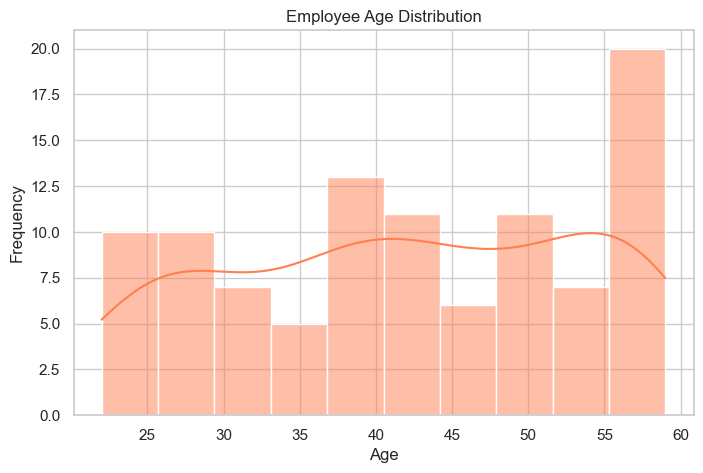

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=10, kde=True, color='coral')
plt.title('Employee Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()